### **Lembar Kerja Praktikum:**
* Mata Kuliah :BDDM
* Pertemuan Ke : 24
* CPMK: Mahasiswa Mampu Menerapkan Metode Analisis Data (CPMK 21)
* Sub CPMK: Mahasiswa dapat menjelaskan konsep dasar dan cara kerja algoritma clustering (un-supervised learning) (SCPMK 1682111)
* Indikator Keberhasilan: Mahasiswa penyelesaian contoh kasus clustering dalam bahasa pemrograman

### **Identitas Praktikan:**
* Nama: Yezha Amanando
* Nim: 23.11.5629
* Kelas: IF05

### **Petunjuk Praktikum:**
* LINK DATASET: https://s.amikom.ac.id/DATASET-MALLCUSTOMER

### **Tujuan Praktikum**
1. Mengidentifikasi core point, border point, dan noise
2. Mengimplementasikan DBSCAN pada data numerik
3. Menganalisis Pengaruh Epslion dan Mint Points
4. Mencari Epsilon dan Mint points yang optimal

**Import Library**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler


**MEMBUAT DATA SINTETIS**

In [ ]:
#create syntetic data
X, y = make_moons(n_samples=300, noise=0.1, random_state=42)
X = StandardScaler().fit_transform(X)


**VISUALISASI AWAL**

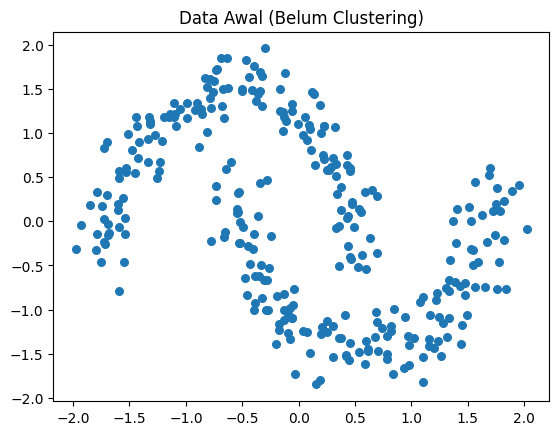

In [ ]:
plt.scatter(X[:,0], X[:,1], s=30)
plt.title("Data Awal (Belum Clustering)")
plt.show()


**CLUSTERING MENGGUNAKAN DBSCAN**

In [ ]:
dbscan = DBSCAN(eps=0.3, min_samples=5)
labels = dbscan.fit_predict(X)


**VISUALISASI HASIL CLUSTERING**

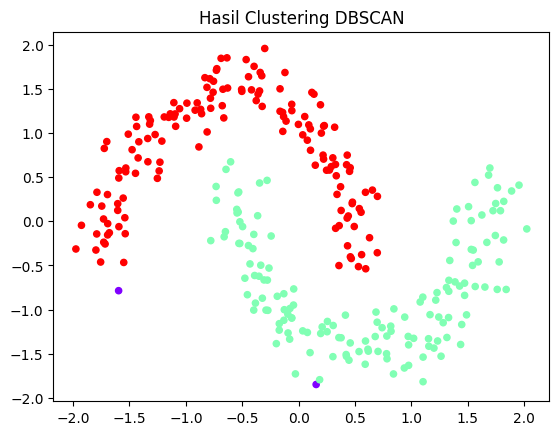

In [ ]:
plt.scatter(X[:,0], X[:,1], c=labels, cmap='rainbow', s=20)
plt.title("Hasil Clustering DBSCAN")
plt.show()


**AMBIL CORE POINT**

In [ ]:
core_indices = dbscan.core_sample_indices_
core_mask = np.zeros(len(X), dtype=bool)
core_mask[core_indices] = True


In [ ]:
print("Daftar Indeks Core Points:")
print(core_indices)

print(f"\nTotal jumlah Core Points: {len(core_indices)}")

Daftar Indeks Core Points:
[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 145
 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163
 164 165 166 167 168 169 170 171 172 173 175 176 177 179 180 181 182 183
 184 185 186 187 188 189 190 192 194 195 196 197 198 199 200 201 202 203
 204 205 206 207 208 209 210 211 212 213 214 216 217 218 219 220 221 222
 224 225 226 227 228 229 230 231 232 233 234 235 236 237 238 239 242 243
 244 245 246 247 248 249

In [ ]:
print("Isi Core Mask (True = Core Point):")
print(core_mask)

print("\nDistribusi Core vs Non-Core:")
print(pd.Series(core_mask).value_counts())

Isi Core Mask (True = Core Point):
[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True False  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
 False  True  True  True  True  True  True  True  True  True  True  True
  True  True  Tr

**IDENTIFIKASI BORDER POINT**

In [ ]:
border_mask = (labels != -1) & (~core_mask)


In [ ]:
print("Array Core Mask:")
print(core_mask)

print(f"\nJumlah Core Points  : {core_mask.sum()}")
print(f"Jumlah Border Points: {border_mask.sum()}")

Array Core Mask:
[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True False  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
 False  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  Tr

IDENTIFIKASI NOISE

In [ ]:
noise=X[labels==-1]

In [ ]:
noise

array([[-1.59615919, -0.78652881],
       [ 0.15489551, -1.84913949]])

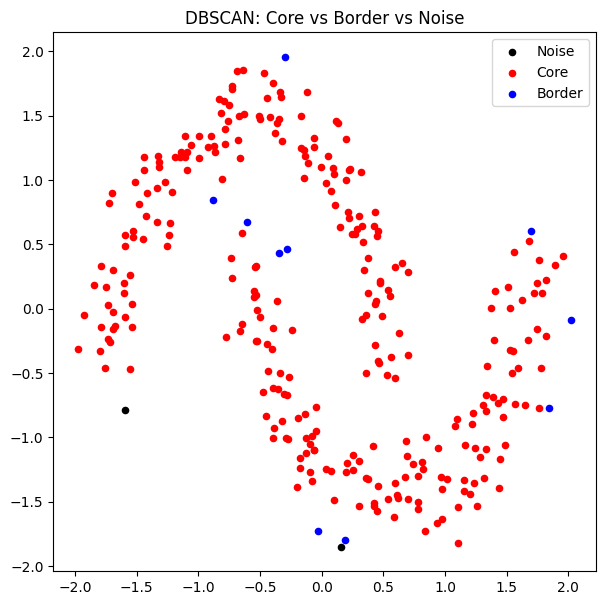

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

# Noise
plt.scatter(X[labels == -1, 0], X[labels == -1, 1],
            c='black', s=20, label='Noise')

# Core points
plt.scatter(X[core_mask, 0], X[core_mask, 1],
            c='red', s=20, label='Core')

# Border points
plt.scatter(X[border_mask, 0], X[border_mask, 1],
            c='blue', s=20, label='Border')

plt.legend()
plt.title("DBSCAN: Core vs Border vs Noise")
plt.show()


In [ ]:
n_noise = np.sum(labels == -1)
n_core = np.sum(core_mask)
n_border = np.sum(border_mask)

print(f"Jumlah Noise points  : {n_noise}")
print(f"Jumlah Core points   : {n_core}")
print(f"Jumlah Border points : {n_border}")
print(f"Total seluruh data   : {len(X)}")

Jumlah Noise points  : 2
Jumlah Core points   : 288
Jumlah Border points : 10
Total seluruh data   : 300


**ANALISA PENGARUH EPSILON DAN MIN POINTS**

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from itertools import product
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN

import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv('/content/Mall_Customers.csv')

In [ ]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


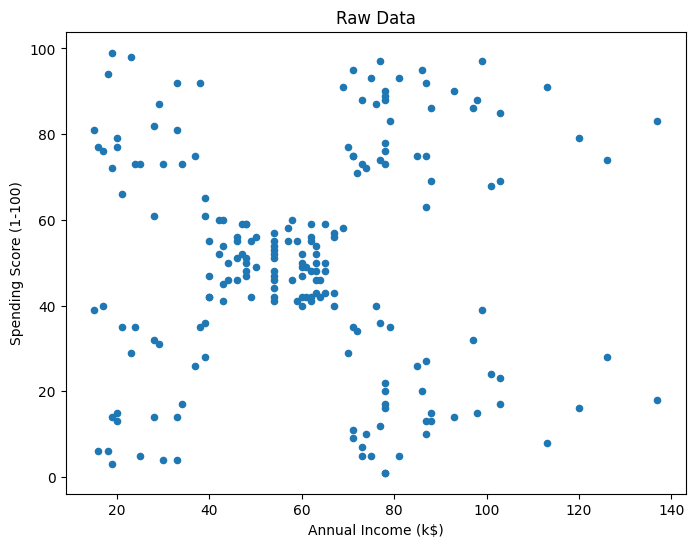

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], s = 20) #Point size is 20
plt.title('Raw Data')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

In [ ]:
X = df[[ 'Annual Income (k$)', 'Spending Score (1-100)']]

In [ ]:
eps = 10
min_samples = 5

db = DBSCAN(eps=eps, min_samples=min_samples)
labels = db.fit_predict(X)

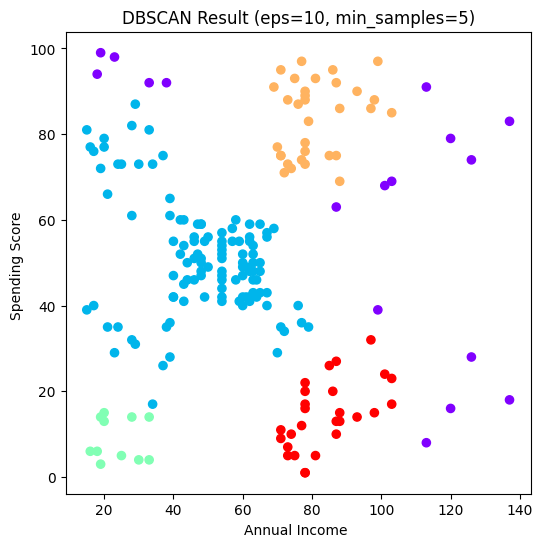

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(X.iloc[:,0], X.iloc[:,1], c=labels, cmap="rainbow", s=35)
plt.title(f"DBSCAN Result (eps={eps}, min_samples={min_samples})")
plt.xlabel("Annual Income ")
plt.ylabel("Spending Score ")
plt.show()

In [ ]:
df["dbscan_cluster"] = labels
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),dbscan_cluster
0,1,Male,19,15,39,0
1,2,Male,21,15,81,0
2,3,Female,20,16,6,1
3,4,Female,23,16,77,0
4,5,Female,31,17,40,0


In [ ]:
df["dbscan_cluster"].value_counts().sort_index()


,count
dbscan_cluster,
-1,17
0,113
1,11
2,32
3,27


In [ ]:
siluet=silhouette_score(X,labels)
print(siluet)

0.41249187303464097


db.2

In [ ]:
eps = 2
min_samples = 5

db2 = DBSCAN(eps=eps, min_samples=min_samples)
labels = db2.fit_predict(X)

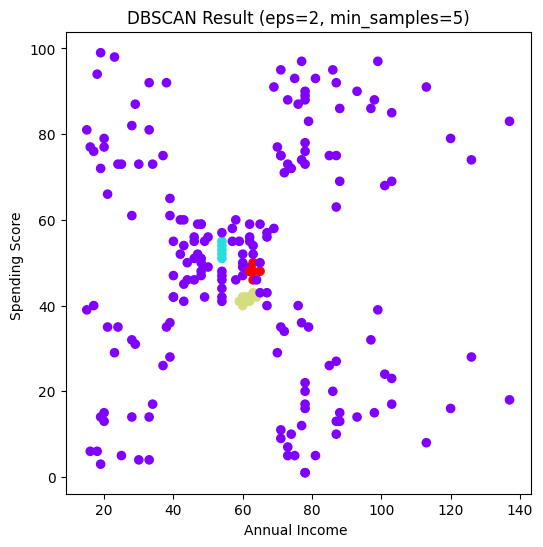

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(X.iloc[:,0], X.iloc[:,1], c=labels, cmap="rainbow", s=35)
plt.title(f"DBSCAN Result (eps={eps}, min_samples={min_samples})")
plt.xlabel("Annual Income ")
plt.ylabel("Spending Score ")
plt.show()

In [ ]:
df["dbscan_cluster"] = labels
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),dbscan_cluster
0,1,Male,19,15,39,-1
1,2,Male,21,15,81,-1
2,3,Female,20,16,6,-1
3,4,Female,23,16,77,-1
4,5,Female,31,17,40,-1


In [ ]:
df["dbscan_cluster"].value_counts().sort_index()

,count
dbscan_cluster,
-1,182
0,5
1,8
2,5


In [ ]:
siluet=silhouette_score(X,labels)
print(siluet)

-0.3384933492468103


db.5

In [ ]:
eps = 5
min_samples = 5

db5 = DBSCAN(eps=eps, min_samples=min_samples)
labels = db5.fit_predict(X)

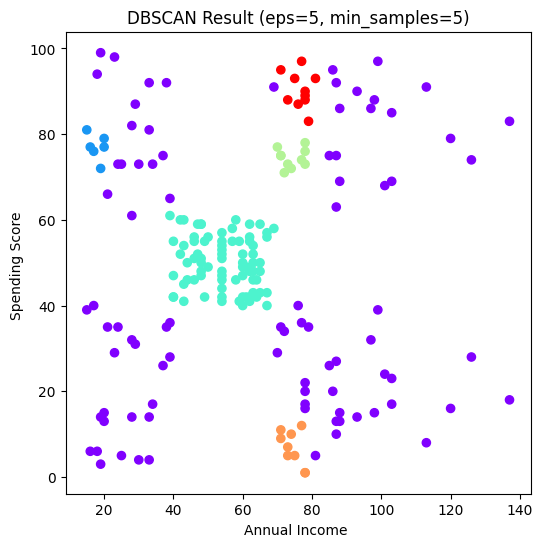

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(X.iloc[:,0], X.iloc[:,1], c=labels, cmap="rainbow", s=35)
plt.title(f"DBSCAN Result (eps={eps}, min_samples={min_samples})")
plt.xlabel("Annual Income ")
plt.ylabel("Spending Score ")
plt.show()

In [ ]:
df["dbscan_cluster"] = labels
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),dbscan_cluster
0,1,Male,19,15,39,-1
1,2,Male,21,15,81,0
2,3,Female,20,16,6,-1
3,4,Female,23,16,77,0
4,5,Female,31,17,40,-1


In [ ]:
df["dbscan_cluster"].value_counts().sort_index()

,count
dbscan_cluster,
-1,87
0,6
1,78
2,10
3,9
4,10


In [ ]:
siluet=silhouette_score(X,labels)
print(siluet)

0.1135163893571667


db.10

In [ ]:
eps = 10
min_samples = 10

db10 = DBSCAN(eps=eps, min_samples=min_samples)
labels = db10.fit_predict(X)

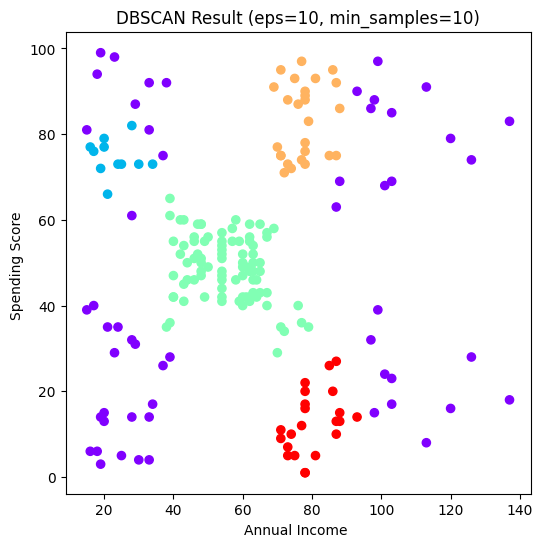

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(X.iloc[:,0], X.iloc[:,1], c=labels, cmap="rainbow", s=35)
plt.title(f"DBSCAN Result (eps={eps}, min_samples={min_samples})")
plt.xlabel("Annual Income ")
plt.ylabel("Spending Score ")
plt.show()

In [ ]:
df["dbscan_cluster"] = labels
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),dbscan_cluster
0,1,Male,19,15,39,-1
1,2,Male,21,15,81,-1
2,3,Female,20,16,6,-1
3,4,Female,23,16,77,0
4,5,Female,31,17,40,-1


In [ ]:
df["dbscan_cluster"].value_counts().sort_index()

,count
dbscan_cluster,
-1,54
0,11
1,87
2,26
3,22


In [ ]:
siluet=silhouette_score(X,labels)
print(siluet)

0.30375625528880634


db.3

In [ ]:
eps = 10
min_samples = 3

db3 = DBSCAN(eps=eps, min_samples=min_samples)
labels = db3.fit_predict(X)

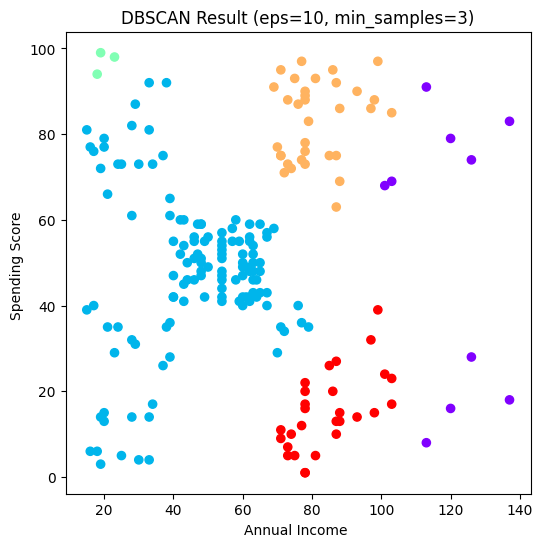

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(X.iloc[:,0], X.iloc[:,1], c=labels, cmap="rainbow", s=35)
plt.title(f"DBSCAN Result (eps={eps}, min_samples={min_samples})")
plt.xlabel("Annual Income ")
plt.ylabel("Spending Score ")
plt.show()

In [ ]:
df["dbscan_cluster"] = labels
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),dbscan_cluster
0,1,Male,19,15,39,0
1,2,Male,21,15,81,0
2,3,Female,20,16,6,0
3,4,Female,23,16,77,0
4,5,Female,31,17,40,0


In [ ]:
df["dbscan_cluster"].value_counts().sort_index()

,count
dbscan_cluster,
-1,10
0,126
1,3
2,33
3,28


In [ ]:
siluet=silhouette_score(X,labels)
print(siluet)

0.36270289706345077


Analisis:

Perbedaan utama pada model DBSCAN yang telah dilakukan terletak pada parameter eps dan min_samples yang secara langsung mempengaruhi silhouette score,lebih tinggi membuat cluster lebih ketat,lebih rendah membuat cluster kurang kohesif,hal ini menunjukkan bahwa parameter eps dan min_samples harus seimbang untuk mendapatkan hasil yang maksimal.di percobaan yang sudah dilakukan model yang paling baik tetap yang awal yang epsnya 10 dan min_samplesnya 5,akan tetapi jika hanya melihat yang db2,5,10,dan 3 db 3 lah yang paling baik karena memiliki silhouette score tertinggi.

**MENCARI NILAI EPSILON DAN MINPOINT YANG OPTIMAL**

In [ ]:
eps_values = np.arange(8,12.75,0.25) #parameter dalam range >=8 & <12.75 dengan kelipatan 0.25
min_points = np.arange(3,10) #parameter dalam range >=3 & <10 dengan kelipatan 1

DBSCAN_params = list(product(eps_values, min_points))
DBSCAN_params[:10]

[(np.float64(8.0), np.int64(3)),
 (np.float64(8.0), np.int64(4)),
 (np.float64(8.0), np.int64(5)),
 (np.float64(8.0), np.int64(6)),
 (np.float64(8.0), np.int64(7)),
 (np.float64(8.0), np.int64(8)),
 (np.float64(8.0), np.int64(9)),
 (np.float64(8.25), np.int64(3)),
 (np.float64(8.25), np.int64(4)),
 (np.float64(8.25), np.int64(5))]

In [ ]:
#melakukan iterasi untuk menghitung silhouette score berdasarkan kombinasi parameter

no_of_clusters = []
sil_score = []

for p in DBSCAN_params:
    DBS_clustering = DBSCAN(eps=p[0], min_samples=p[1]).fit(X)
    no_of_clusters.append(len(np.unique(DBS_clustering.labels_)))
    sil_score.append(silhouette_score(X, DBS_clustering.labels_))

In [ ]:
sil_score

[np.float64(0.4466832173019108),
 np.float64(0.3888444498053395),
 np.float64(0.3550982050619174),
 np.float64(0.28838622272538006),
 np.float64(0.22856372682502918),
 np.float64(0.23130655888279378),
 np.float64(0.15874670998673038),
 np.float64(0.46403608560805165),
 np.float64(0.41461622960696004),
 np.float64(0.39201313128562093),
 np.float64(0.3392781429643879),
 np.float64(0.24232188104578023),
 np.float64(0.23159654733166227),
 np.float64(0.17545298910606077),
 np.float64(0.46403608560805165),
 np.float64(0.41461622960696004),
 np.float64(0.39201313128562093),
 np.float64(0.3392781429643879),
 np.float64(0.24232188104578023),
 np.float64(0.23159654733166227),
 np.float64(0.17545298910606077),
 np.float64(0.4704714508042984),
 np.float64(0.419532558337873),
 np.float64(0.4321128619542937),
 np.float64(0.34133299752613233),
 np.float64(0.300305984909528),
 np.float64(0.23895668511168006),
 np.float64(0.19143138639469612),
 np.float64(0.475053701963407),
 np.float64(0.4259680122384

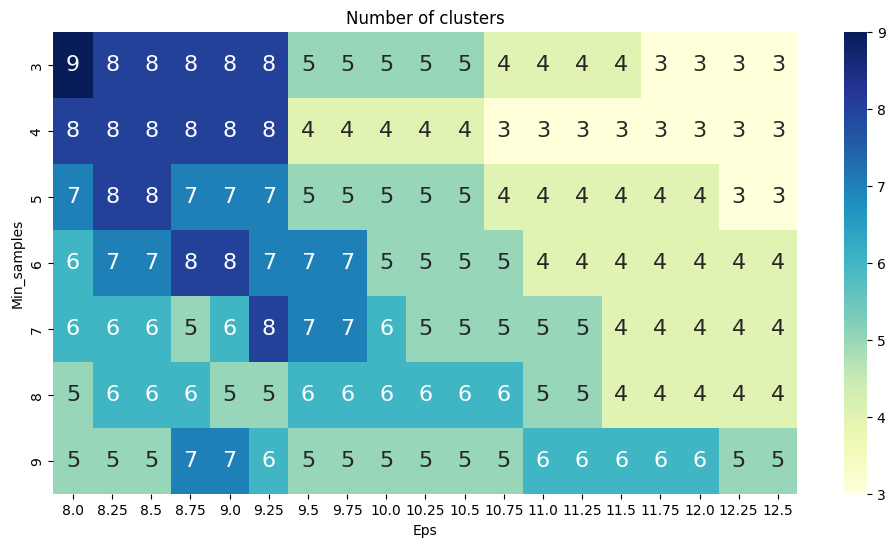

In [ ]:
tmp = pd.DataFrame.from_records(DBSCAN_params, columns =['Eps', 'Min_samples'])
tmp['No_of_clusters'] = no_of_clusters

pivot_1 = pd.pivot_table(tmp, values='No_of_clusters', index='Min_samples', columns='Eps')

fig, ax = plt.subplots(figsize=(12,6))
sns.heatmap(pivot_1, annot=True,annot_kws={"size": 16}, cmap="YlGnBu", ax=ax)
ax.set_title('Number of clusters')
plt.show()

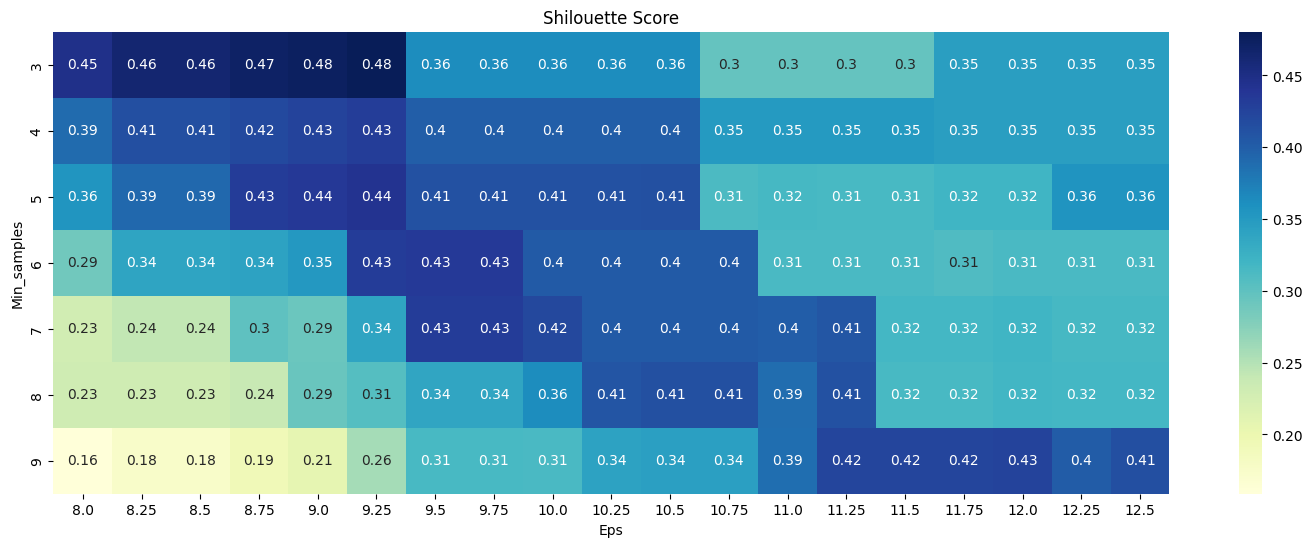

In [ ]:
tmp = pd.DataFrame.from_records(DBSCAN_params, columns =['Eps', 'Min_samples'])
tmp['Sil_score'] = sil_score

pivot_1 = pd.pivot_table(tmp, values='Sil_score', index='Min_samples', columns='Eps')

fig, ax = plt.subplots(figsize=(18,6))
sns.heatmap(pivot_1, annot=True, annot_kws={"size": 10}, cmap="YlGnBu", ax=ax)
ax.set_title('Shilouette Score')
plt.show()

Model.grid

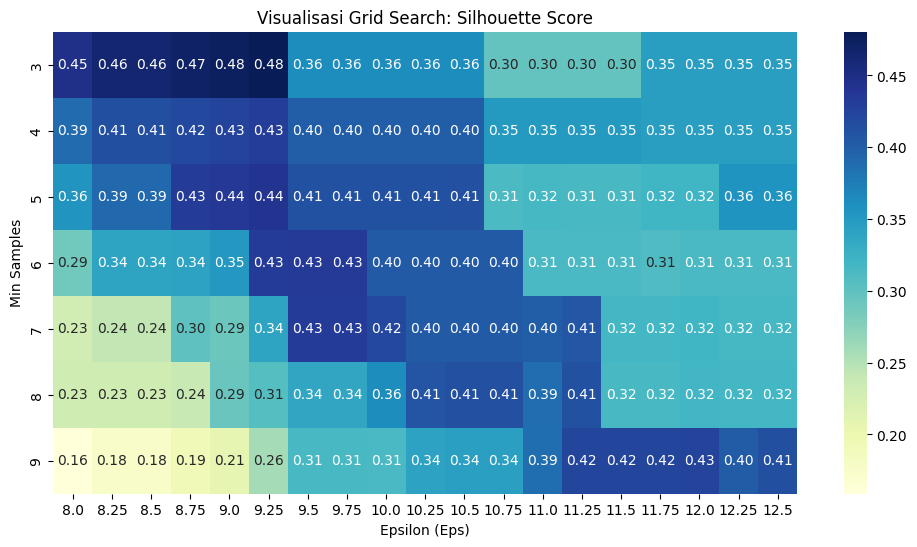

In [ ]:
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_1, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Visualisasi Grid Search: Silhouette Score")
plt.xlabel("Epsilon (Eps)")
plt.ylabel("Min Samples")
plt.show()

Model.knee

In [ ]:
# install jika perlu: pip install kneed
!pip install kneed
from kneed import KneeLocator

In [ ]:
from sklearn.neighbors import NearestNeighbors
MinPts = 4  # min_samples DBSCAN

# 1) hitung k-distance
nbrs = NearestNeighbors(n_neighbors=MinPts).fit(X)
distances, _ = nbrs.kneighbors(X)
k_distances = np.sort(distances[:, MinPts-1])

# 2) cari knee

x = np.arange(len(k_distances))
knee = KneeLocator(x, k_distances, curve="convex", direction="increasing")
eps_opt = k_distances[knee.knee]

In [ ]:
print("Index knee:", knee.knee)
print("Epsilon optimal:", eps_opt)

Index knee: 176
Epsilon optimal: 10.0


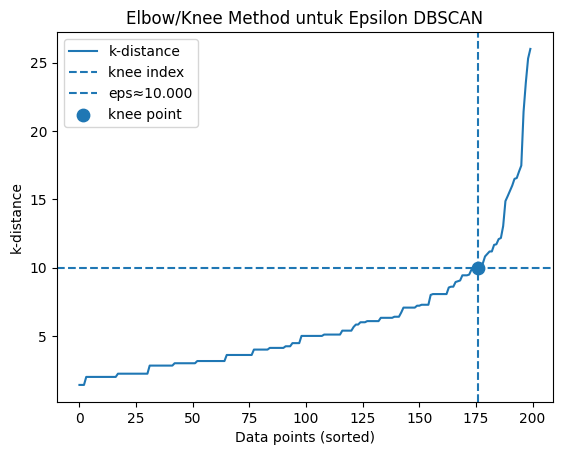

In [ ]:
# 3) plot + titik knee
plt.figure()
plt.plot(x, k_distances, label="k-distance")
plt.axvline(knee.knee, linestyle="--", label="knee index")
plt.axhline(eps_opt, linestyle="--", label=f"eps≈{eps_opt:.3f}")
plt.scatter([knee.knee], [eps_opt], s=80, zorder=3, label="knee point")
plt.title("Elbow/Knee Method untuk Epsilon DBSCAN")
plt.xlabel("Data points (sorted)")
plt.ylabel("k-distance")
plt.legend()
plt.show()